## Setup

In [1]:
import json

#get params
with open("./params.json", mode = "r", encoding = "utf-8") as f:
    data = json.load(f)
    seed_vals = data["seed_vals"]
    ensemble_root_path = data["ensemble_root_path"]
    dataset_path_test_stream_windowed = data["dataset_path"]["test"]["stream"]["windowed"]
    dataset_path_test_stream_full = data["dataset_path"]["test"]["stream"]["full"]
    dataset_path_test_reversal_windowed = data["dataset_path"]["test"]["reversal"]["windowed"]
    dataset_path_test_reversal_full = data["dataset_path"]["test"]["reversal"]["full"]
    stats_path = data["stats_path"]
    num_single_sample_timesteps = data["num_single_sample_timesteps"]
    input_window_length = data["input_window_length"]
    label_window_length = data["label_window_length"]
    valid_length = input_window_length + label_window_length
    input_features = data["input_features"]
    label_features = data["label_features"]
    extra_features = data["extra_features"]
    num_label_features = len(label_features)
    window_stride = data["window_stride"]
    num_datapoints_per_timeseries = len(
        list(
            range(
                0, num_single_sample_timesteps - (input_window_length + label_window_length) + 1, window_stride
            )
        )
    )
    # num_datapoints_per_timeseries = 1 + (num_single_sample_timesteps - (input_window_length + label_window_length) + 1) // window_stride

    seed_val = 0

    # Use for kdeplot inference
    batch_size = data["batch_size"]

In [2]:
import torch
import random
import numpy as np
import pandas as pd
from scipy import stats as stats_module

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(seed_val)
random.seed(seed_val)
np.random.seed(seed_val)

In [3]:
# from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import ipywidgets as widgets
import polars as pl

from utils.pipeline.Model import TimeSeriesHuggingFaceTransformer
# from utils.pipeline.Data import get_mean_std_respected_temporal, WindowedIterableDataset, read_stats
from utils.pipeline.Data import InferenceAnalysisDataset, WindowedDataset
from utils.pipeline.Run import forward_pass

In [4]:
### REVERSALS ###

stats = pl.read_csv(stats_path)

df_test = InferenceAnalysisDataset(
    windowed_dataset_path = dataset_path_test_reversal_windowed,
    full_dataset_path = dataset_path_test_reversal_full,
    index_full_update_len = num_datapoints_per_timeseries
)

In [23]:
### Global Params
num_timeseries = 803
first_window = 69

#model paths|
model_paths = [
    f"{ensemble_root_path}/22/T5-{input_window_length}-{label_window_length}-{window_stride}-{val}.pt" for val in seed_vals
]

## Computations

### Reversal Probabilities

In [ ]:
#Get the number of models that predict a reversal (reversal probability) for windows 69-79 for all timeseries

chunk_size = 128

#create dataframes to hold the reversal probabilities
original_reversal_probs = pd.DataFrame(
    index=range(num_timeseries),
    columns=[str(j) for j in range(first_window, 80)],
)

normal_reversal_probs = pd.DataFrame(
    index=range(num_timeseries),
    columns=[str(j) for j in range(first_window, 80)],
)

good_reversal_probs = pd.DataFrame(
    index=range(num_timeseries),
    columns=[str(j) for j in range(first_window, 80)],
)


num_windows = 80 - first_window

#build a grid of window-timeseries pairs
i_grid, j_grid = np.meshgrid(
    np.arange(num_timeseries), np.arange(first_window, 80), indexing="ij"
)
i_flat = i_grid.flatten()
j_flat = j_grid.flatten()
data_indices = i_flat * num_datapoints_per_timeseries + j_flat
N = data_indices.shape[0]

#get an array of windows; each index is a specific window-timeseries pair
windows_x = np.asarray(df_test.inputs_windowed[data_indices]) 
windows_y = np.asarray(df_test.labels_windowed[data_indices])

#similarly, get arrays for label features and extra features
index_full = data_indices // df_test.index_full_update_len
labels_full_batch = np.asarray(df_test.labels_full[index_full])
extras_full_batch = np.asarray(df_test.extras_full[index_full])

#make the numpy arrays torch tensors?
batch_x = torch.from_numpy(windows_x).float().to(device)
batch_y = torch.from_numpy(windows_y).float().to(device) 
x_labels = torch.from_numpy(labels_full_batch).float()
extra_full = torch.from_numpy(extras_full_batch).float()

#empty tensor/array for predictions/losses
all_preds = torch.zeros((len(model_paths), N) + batch_y.shape[1:])
#all_attns = torch.zeros((len(model_paths), N, label_window_length, input_window_length))
losses = np.zeros((len(model_paths), N))

#L1 loss as our loss function
criterion = torch.nn.L1Loss(reduction="none")

#for every model in the ensemble
for model_idx, path in enumerate(model_paths):

    #load the model
    model = torch.load(path, map_location=device, weights_only=False).to(device)
    model.eval()

    #needed because we're only doing forward passes; no backpropagation
    with torch.no_grad():
        #loop through all data in chunks
        for start in range(0, N, chunk_size):
            end = min(start + chunk_size, N)

            #forward pass of the model with the specific chunk of data
            outputs = forward_pass(
                model=model,
                batch_x=batch_x[start:end],
                device=device,
                extract_attention=True
            )

            #get the predictions
            preds = outputs.logits

            #calculate loss for each model and timeseries?
            per_sample_loss = criterion(preds, batch_y[start:end]).mean(dim=(1, 2))

            #put the predictions/losses into the tensor/array
            all_preds[model_idx, start:end] = preds.cpu()
            #all_attns[model_idx, start:end] = model.get_average_attention_values()  # will be silently wrong if uncommented
            losses[model_idx, start:end] = per_sample_loss.cpu().numpy()

    del model
    torch.cuda.empty_cache()

#get what index u_list is in the list of label features
#at time of writing, u_idx is 2 because label_features is ("b_e", "b_plus", "u_list")
u_idx = label_features.index("u_list")

#get number of models
num_models = len(model_paths)

#get predictions for U from the first and last timestep in a timeseries-window pair
first_timesteps = all_preds[:, :, 0, u_idx]
last_timesteps = all_preds[:, :, -1, u_idx]

##check whether there was a reserval event based on different criteria
#original criterion used. First timestep positive and last timestep negative. Misses some predicted reservals when last U in window is positive, but first prediction is negative
pred_reversal_original = (torch.sign(first_timesteps) != torch.sign(last_timesteps))
pred_reversal_original = pred_reversal_original.reshape(num_models, num_timeseries, num_windows)

#new criterion used. Last timestep is negative. Only works for reversal event data
pred_reversal_normal = (last_timesteps < 0)
pred_reversal_normal = pred_reversal_normal.reshape(num_models, num_timeseries, num_windows)

#criterion used to asses whether reversal was predicted at roughly the correst time. Does not count as a predicted reversal if prediction crosses u=0 too early (too much error)
pred_reversal_good = ((last_timesteps < 0) & (torch.from_numpy(losses) < 1))
pred_reversal_good = pred_reversal_good.reshape(num_models, num_timeseries, num_windows)


##check whether there was a reserval event based on different criteria
#original criterion used. First timestep positive and last timestep negative. Misses some predicted reservals when last U in window is positive, but first prediction is negative
count_pred_reversal_original = (torch.sign(first_timesteps) != torch.sign(last_timesteps)).sum(dim=0).numpy()
#new criterion used. Last timestep is negative. Only works for reversal event data
count_pred_reversal_normal = (last_timesteps.numpy() < 0).sum(axis=0)
#criterion used to asses whether reversal was predicted at roughly the correst time. Does not count as a predicted reversal if prediction crosses u=0 too early (too much error)
count_pred_reversal_good = ((last_timesteps.numpy() < 0) & (losses < 1)).sum(axis=0)     



#get probabilities
original_reversal_prob = (count_pred_reversal_original/num_models)*100 
normal_reversal_prob = (count_pred_reversal_normal/num_models)*100 
good_reversal_prob = (count_pred_reversal_good/num_models)*100

#Reshape 1d arrays/tensors into priorly created dataframes
original_reversal_probs.iloc[:, :] = original_reversal_prob.reshape(num_timeseries, num_windows)
normal_reversal_probs.iloc[:, :] = normal_reversal_prob.reshape(num_timeseries, num_windows)
good_reversal_probs.iloc[:, :] = good_reversal_prob.reshape(num_timeseries, num_windows)

#reshape preds (10, 803, 11, 50, 3)
preds = all_preds.reshape(num_models, num_timeseries, num_windows, 50, len(label_features))

In [80]:
#save reversal probabilities dataframes as csv files so we don't need to run the above code every time (takes ~10 minutes on my machine)
original_reversal_probs.to_csv('./analysis/reversal_probs/original_reversal_probs.csv', index=False)
normal_reversal_probs.to_csv('./analysis/reversal_probs/normal_reversal_probs.csv', index=False)
good_reversal_probs.to_csv('./analysis/reversal_probs/good_reversal_probs.csv', index=False)

#save reversal predictions by model
torch.save(pred_reversal_original, './analysis/reversal_prediction_by_model/pred_reversal_original.pt')
torch.save(pred_reversal_normal, './analysis/reversal_prediction_by_model/pred_reversal_normal.pt')
torch.save(pred_reversal_good, './analysis/reversal_prediction_by_model/pred_reversal_good.pt')

#save predictions
torch.save(preds, './analysis/full_preds.pt')

In [79]:
preds = all_preds.reshape(num_models, num_timeseries, num_windows, 50, len(label_features))

torch.Size([10, 8833, 50, 3])
(50, 3)


<function matplotlib.pyplot.show(close=None, block=None)>

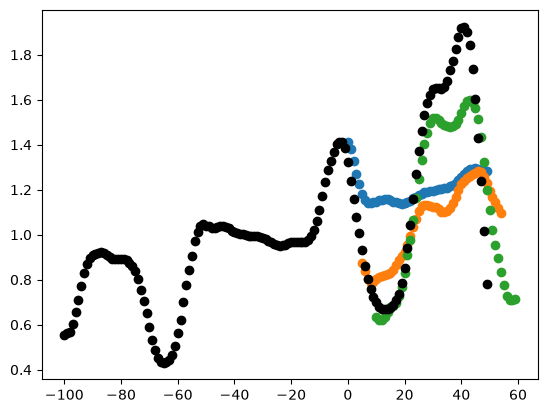

In [78]:
print(all_preds.shape)
#803 timeseries
#11 windows

preds = all_preds.reshape(10, 803, 11, 50, 3)

windows_x = np.asarray(df_test.inputs_windowed[69 + num_datapoints_per_timeseries]) 
windows_y = np.asarray(df_test.labels_windowed[69 + num_datapoints_per_timeseries])

print(windows_y.shape)



plt.scatter(np.arange(0, 50), preds[0, 1, 0, :, 2], marker='o')
plt.scatter(np.arange(5, 55), preds[0, 1, 1, :, 2], marker='o')
plt.scatter(np.arange(10, 60), preds[0, 1, 2, :, 2], marker='o')
plt.scatter(np.arange(-100, 0), windows_x[:, 2], marker='o', color = "black")
plt.scatter(np.arange(0, 50), windows_y[:, 2], marker='o', color = "black")

plt.show

### Feature Sorting by Reversal Probabilities

In [79]:
reversal_probs = original_reversal_probs

#empty tensors
features_100 = []
features_high = []
features_mid = []
features_low = []
features_0 = []

#loop through windows
for window_idx in (reversal_probs.columns):

    #current window index as an integer
    selected_window_idx = int(window_idx)

    #temporary tensors
    temp_100 = []
    temp_high = []
    temp_mid = []
    temp_low = []
    temp_0 = []

    #for each timeseries (at the specific window)
    for i in range(num_timeseries):
        #current timeseries
        target_timeseries_idx = i

        #index in the 1d array
        data_idx = target_timeseries_idx * num_datapoints_per_timeseries + selected_window_idx
        window_x, window_y, x_labels, extra_full = df_test[data_idx]

        #grab the reversal probability for the current timeseries and window index
        reversal_prob = reversal_probs[window_idx][target_timeseries_idx]

        #sort based on reversal probabilities and add to temporary tensors
        if(reversal_prob == 100):
            temp_100.append(window_x)
        if(reversal_prob >= 80):
            temp_high.append(window_x)
        if((reversal_prob < 80) & (reversal_prob > 20)):
            temp_mid.append(window_x)
        if(reversal_prob <= 20):
            temp_low.append(window_x)
        if(reversal_prob == 0):
            temp_0.append(window_x)

    #add temporary tensors to actual tensors
    features_100.append(torch.stack(temp_100) if temp_100 else torch.empty(0))
    features_high.append(torch.stack(temp_high) if temp_high else torch.empty(0))
    features_mid.append(torch.stack(temp_mid) if temp_mid else torch.empty(0))
    features_low.append(torch.stack(temp_low) if temp_low else torch.empty(0))
    features_0.append(torch.stack(temp_0) if temp_0 else torch.empty(0))


In [80]:
#save tensors so we don't need to run the above code every time (takes ~10 minutes on my machine)
torch.save(features_100, './analysis/features_sorted_by_reversal_probs/original_features_100.pt')
torch.save(features_high, './analysis/features_sorted_by_reversal_probs/original_features_high.pt')
torch.save(features_mid, './analysis/features_sorted_by_reversal_probs/original_features_mid.pt')
torch.save(features_low, './analysis/features_sorted_by_reversal_probs/original_features_low.pt')
torch.save(features_0, './analysis/features_sorted_by_reversal_probs/original_features_0.pt')

## Analysis

In [ ]:
#read csv files
original_reversal_probs = pd.read_csv('./analysis/reversal_probs/original_reversal_probs.csv')
normal_reversal_probs = pd.read_csv('./analysis/reversal_probs/normal_reversal_probs.csv')
good_reversal_probs = pd.read_csv('./analysis/reversal_probs/good_reversal_probs.csv')

original_pred_reversal = torch.load('./analysis/reversal_prediction_by_model/pred_reversal_original.pt')
normal_pred_reversal = torch.load('./analysis/reversal_prediction_by_model/normal_pred_reversal.pt')
good_pred_reversal = torch.load('./analysis/reversal_prediction_by_model/pred_reversal_good.pt')

original_features_100 = torch.load('./analysis/features_sorted_by_reversal_probs/original_features_100.pt')
original_features_high = torch.load('./analysis/features_sorted_by_reversal_probs/original_features_high.pt')
original_features_mid = torch.load('./analysis/features_sorted_by_reversal_probs/original_features_mid.pt')
original_features_low = torch.load('./analysis/features_sorted_by_reversal_probs/original_features_low.pt')
original_features_0 = torch.load('./analysis/features_sorted_by_reversal_probs/original_features_0.pt')

normal_features_100 = torch.load('./analysis/features_sorted_by_reversal_probs/normal_features_100.pt')
normal_features_high = torch.load('./analysis/features_sorted_by_reversal_probs/normal_features_high.pt')
normal_features_mid = torch.load('./analysis/features_sorted_by_reversal_probs/normal_features_mid.pt')
normal_features_low = torch.load('./analysis/features_sorted_by_reversal_probs/normal_features_low.pt')
normal_features_0 = torch.load('./analysis/features_sorted_by_reversal_probs/normal_features_0.pt')

good_features_100 = torch.load('./analysis/features_sorted_by_reversal_probs/good_features_100.pt')
good_features_high = torch.load('./analysis/features_sorted_by_reversal_probs/good_features_high.pt')
good_features_mid = torch.load('./analysis/features_sorted_by_reversal_probs/good_features_mid.pt')
good_features_low = torch.load('./analysis/features_sorted_by_reversal_probs/good_features_low.pt')
good_features_0 = torch.load('./analysis/features_sorted_by_reversal_probs/good_features_0.pt')

#full preds
full_preds = torch.load('./analysis/full_preds.pt')

In [7]:
#Lists
colors = ['#00b7ff', '#d4e000', '#d20b64', '#0037FA', '#7A0000']
feature_list = ["b_e", "b_plus", "U"]
summary_stat_list = ["Mean", "Median", "Std", "Min", "Max", "Range"]
prediction_type_list = ["Original", "Normal", "Good"]

reversal_probs_list = [original_reversal_probs, normal_reversal_probs, good_reversal_probs]
pred_reversal_list = [original_pred_reversal, normal_pred_reversal, good_pred_reversal]

features = [[original_features_100, normal_features_100, good_features_100],
            [original_features_high, normal_features_high, good_features_high],
            [original_features_mid, normal_features_mid, good_features_mid],
            [original_features_low, normal_features_low, good_features_low],
            [original_features_0, normal_features_0, good_features_0]]


In [8]:
#definition to calculate the relevant summary statistic for a tensor of data based on the window, window subset, feature, and axis
def calculate_summary_stat(tensor, summary_stat, window_idx, window_subset_start, window_subset_end, feature_num, axis):
        #empty array
        return_array = []

        #get relevant data as array
        subset = np.asarray(tensor[window_idx - first_window][:, window_subset_start:window_subset_end, feature_num])

        if (summary_stat == "Mean"):
                return_array =  subset.mean(axis = axis)
        elif (summary_stat == "Median"):
                return_array = np.median(subset, axis = axis)
        elif (summary_stat == "Std"):
                return_array = subset.std(axis = axis)
        elif (summary_stat == "Min"):
                return_array = np.min(subset, axis = axis)
        elif (summary_stat == "Max"):
                return_array = np.max(subset, axis = axis)
        elif (summary_stat == "Range"):
                return_array = np.ptp(subset, axis = axis)

        return return_array

### Prediction Horizon

In [9]:
#### Define Function####
def bar_of_prediction_horizon(
        prediction_type
    ):

    #vars
    num_windows = 80 - first_window

    prediction_type_number = prediction_type_list.index(prediction_type)
    reversal_probs = reversal_probs_list[prediction_type_number]

    #How many timeseries fit into each reversal_prob category for each window index
    counts_100 = (reversal_probs == 100).sum(axis=0).to_numpy()/np.full(num_windows, num_timeseries/100)
    counts_high = (reversal_probs >= 80).sum(axis=0).to_numpy()/np.full(num_windows, num_timeseries/100)
    counts_low = (reversal_probs <= 20).sum(axis=0).to_numpy()/np.full(num_windows, num_timeseries/100)
    counts_0 = (reversal_probs == 0).sum(axis=0).to_numpy()/np.full(num_windows, num_timeseries/100)
    counts_mid = (np.full(num_windows, 100) - counts_high - counts_low)

    #get the average reversal_prob for the three types of reversal_prob
    averages = [x.mean().to_numpy() for x in reversal_probs_list]

    #print the averages
    print(averages[prediction_type_number].round(1))

    #arrays for where 100s and 0s should go on graph
    tick_100_y = counts_100
    tick_0_y = 100 - counts_0

    #write data as a dataframe
    data = {
        'Index': reversal_probs.columns,
        'Highs': counts_high,
        'Mids': counts_mid,
        'Lows': counts_low
    }
    df = pd.DataFrame(data).set_index('Index')

    fig, ax = plt.subplots(figsize=(7, 5))

    #plot data
    df.plot(kind='bar', stacked=True, ax=ax, width=0.5, color = colors)


    bar_width = 0.5
    xticks = ax.get_xticks()

    #add 100 and 0 dashes
    ax.hlines(tick_100_y, xticks - bar_width/2, xticks + bar_width/2, color='black', linewidth=2, zorder=5)
    ax.hlines(tick_0_y, xticks - bar_width/2, xticks + bar_width/2, color='black', linewidth=2, zorder=5)

    #plot lines for averages
    ax.plot(ax.get_xticks(), averages[0], color='orange', marker='o', linewidth=2.5, label='Original Average')
    ax.plot(ax.get_xticks(), averages[1], color='blue', marker='o', linewidth=2.5, label='Normal Average')
    ax.plot(ax.get_xticks(), averages[2], color='lightblue', marker='o', linewidth=2.5, label='Good Average')

    ax.legend(loc='lower right')

    plt.ylim(0, 100)

    plt.suptitle('Prediction Horizon', fontsize=16, fontweight='bold')
    plt.title('Reversals Predicted Rate by Index', fontsize=12, color='gray')
    plt.xlabel('Window Index')
    plt.ylabel('Reversals Predicted Rate')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

#### Interface #### 
prediction_type = widgets.Dropdown(
    options = prediction_type_list,
    value = "Normal",
    description = "Prediction Type",
    style = {"description_width": "100px"}
)
ui = widgets.VBox([prediction_type])

#### Display ####
out = widgets.interactive_output(
    bar_of_prediction_horizon,
    {
        "prediction_type": prediction_type
    }
)
display(ui, out)


Output()

### Prediction Horizon by Model

In [10]:
def prediction_horizon_by_model(
        prediction_type
    ):

    num_windows = 80 - first_window

    prediction_type_number = prediction_type_list.index(prediction_type)
    pred_reversal = pred_reversal_list[prediction_type_number]

    mean_by_model = pred_reversal.float().mean(dim = 1).detach().cpu().numpy() * 100

    model_names = [f"Model {i}" for i in range(mean_by_model.shape[0])]  
    timesteps = range(first_window, 80) 

    fig, ax = plt.subplots(figsize=(7, 5))

    for i in range(mean_by_model.shape[0]):
        plt.plot(timesteps, mean_by_model[i], label=model_names[i], marker='o')

    ax.legend(loc='lower right')

    plt.ylim(0, 100)
    plt.xlim(first_window, 79)

    plt.suptitle('Prediction Horizon', fontsize=16, fontweight='bold')
    plt.title('Reversals Predicted Rate by Index', fontsize=12, color='gray')
    plt.xlabel('Window Index')
    plt.ylabel('Reversals Predicted Rate')
    plt.tight_layout()
    plt.show()

#### Interface #### 
prediction_type = widgets.Dropdown(
    options = prediction_type_list,
    value = "Normal",
    description = "Prediction Type",
    style = {"description_width": "100px"}
)
ui = widgets.VBox([prediction_type])

#### Display ####
out = widgets.interactive_output(
    prediction_horizon_by_model,
    {
        "prediction_type": prediction_type
    }
)
display(ui, out)

Output()

### Histogram of Timeseries Subset Summary Stats

In [11]:
#### Define Function####
def hist_of_timeseries_subset_summary_stat(
        window_idx,
        feature_name,
        window_subset,
        summary_statistic,
        show_means,
        prediction_type
    ):

    #vars
    feature_num = feature_list.index(feature_name)
    summary_stat_num = summary_stat_list.index(summary_statistic)
    prediction_type_number = prediction_type_list.index(prediction_type)
    window_subset_start, window_subset_end = window_subset

    fig, ax = plt.subplots(figsize = (7, 5))

    #calculate the summary statistics for the selected settings
    #axis = 1 to get the summary statistic over the window subset
    #features_100_1 = calculate_summary_stat(features[0][prediction_type_number], summary_statistic, window_idx, window_subset_start, window_subset_end, feature_num)
    features_high_1 = calculate_summary_stat(features[1][prediction_type_number], summary_statistic, window_idx, window_subset_start, window_subset_end, feature_num, axis = 1)
    features_mid_1 = calculate_summary_stat(features[2][prediction_type_number], summary_statistic, window_idx, window_subset_start, window_subset_end, feature_num, axis = 1)
    features_low_1 = calculate_summary_stat(features[3][prediction_type_number], summary_statistic, window_idx, window_subset_start, window_subset_end, feature_num, axis = 1)
    #features_0_1 = calculate_summary_stat(features[4][prediction_type_number], summary_statistic, window_idx, window_subset_start, window_subset_end, feature_num)

    #t-test comparing between high and low
    t_stat, p_value = stats_module.ttest_ind(features_high_1, features_low_1, equal_var=False)

    bins = bins_list[summary_stat_num][feature_num]

    #plot the stuff
    #plt.hist(features_100_1, bins, alpha=0.5, histtype='step', color = colors[3], label='100')
    plt.hist(features_high_1, bins, alpha=0.5, histtype='step', color = colors[0], label='High')
    plt.hist(features_mid_1, bins, alpha=0.5, histtype='step', color = colors[1], label='Mid')
    plt.hist(features_low_1, bins, alpha=0.5, histtype='step', color = colors[2], label='Low')
    #plt.hist(features_0_1, bins, alpha=0.5, histtype='step', color = colors[4], label='0')

    #vertical line denoting the mean, if we want
    if(show_means):
        plt.axvline(x=features_high_1.mean(), color=colors[0], linestyle='-', linewidth=1)
        plt.axvline(x=features_mid_1.mean(), color=colors[1], linestyle='-', linewidth=1)
        plt.axvline(x=features_low_1.mean(), color=colors[2], linestyle='-', linewidth=1)

    #print p-value
    plt.text(0.78, 0.69, s=f"p-value = {p_value:.4f}", transform=plt.gca().transAxes, fontsize=8, bbox=dict(facecolor='white', alpha=0.5))

    plt.suptitle(f'Histogram of Timeseries {summary_statistic} of {feature_name}', fontsize=16, fontweight='bold')
    plt.title(f'Window Index: {window_idx}', fontsize=12, color='gray')
    plt.xlabel('Z-Score')
    plt.ylabel('Count')
    plt.legend(title="Reversal Probability", loc='upper right')
    plt.show()

#### Interface #### 
window_idx = widgets.IntSlider(
    value = 72,
    min = 69,
    max = 79,
    step = 1,
    description = "Window Index",
    layout = widgets.Layout(width = "500px"),
    style = {"description_width": "100px"}
)
feature_name = widgets.Dropdown(
    options = feature_list,
    value = "U",
    description = "Feature",
    style = {"description_width": "100px"}
)
summary_statistic = widgets.Dropdown(
    options = summary_stat_list,
    value = "Mean",
    description = "Summary Stat",
    style = {"description_width": "100px"}
)
window_subset = widgets.IntRangeSlider(
    value=[85, 100],   
    min=0,
    max=100,
    step=1,
    description="Window Subset",
    layout=widgets.Layout(width="500px"),
    style={"description_width": "100px"}
)
show_means = widgets.Checkbox(
    value = False,
    description = "Show Average",
    disabled = False,
    indent = True,
    style = {"description_width": "100px"}
)
prediction_type = widgets.Dropdown(
    options = prediction_type_list,
    value = "Normal",
    description = "Prediction Type",
    style = {"description_width": "100px"}
)

bins_list = [[np.linspace(-4, 4, 40), np.linspace(-4, 4, 40), np.linspace(-0.5, 2.5, 30)],
             [np.linspace(-4, 4, 40), np.linspace(-4, 4, 40), np.linspace(-0.5, 2.5, 30)],
             [np.linspace(0, 3, 40), np.linspace(0, 3, 40), np.linspace(0, 1, 30)],
             [np.linspace(-5, 2, 40), np.linspace(-5, 2, 40), np.linspace(-0.5, 2.5, 30)],
             [np.linspace(-2, 5, 40), np.linspace(-2, 5, 40), np.linspace(-0.5, 2.5, 30)],
             [np.linspace(0, 8, 40), np.linspace(0, 8, 40), np.linspace(0, 2, 30)]]
horizontal = widgets.HBox([feature_name, summary_statistic, prediction_type])
ui = widgets.VBox([window_idx, window_subset, show_means])

#### Display ####
out = widgets.interactive_output(
    hist_of_timeseries_subset_summary_stat,
    {
        "window_idx": window_idx,
        "feature_name": feature_name,
        "window_subset": window_subset,
        "summary_statistic": summary_statistic,
        "show_means": show_means,
        "prediction_type": prediction_type
    }
)
display(horizontal, ui, out)


Output()

### Time-Series Plot of Index Summary Stats

In [14]:

#function for a bootstrap confidence interval
def bootstrap_ci(data, summary_stat, axis=0, confidence=0.95, n_boot=2000, seed=None):

    #data as array
    data = np.asarray(data) 

    rng = np.random.default_rng(seed)
    n = data.shape[axis]
    
    out_shape = (n_boot,) + tuple(s for i, s in enumerate(data.shape) if i != axis)
    boot_vals = np.empty(out_shape)
    
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        sample = np.take(data, idx, axis=axis)
        if(summary_stat == "Mean"):
            boot_vals[i] = np.mean(sample, axis=axis)
        elif (summary_stat == "Median"):
            boot_vals[i] = np.median(sample, axis = axis)
        elif (summary_stat == "Std"):
            boot_vals[i] = sample.std(axis = axis)
            
    
    lower = np.percentile(boot_vals, (1 - confidence) / 2 * 100, axis=0)
    upper = np.percentile(boot_vals, (1 + confidence) / 2 * 100, axis=0)
    return lower, upper

#### Define Function####
def timeseries_of_index_summary_stat(
        window_idx,
        feature_name,
        summary_statistic,
        prediction_type
    ):

    #vars
    feature_num = feature_list.index(feature_name)
    summary_stat_num = summary_stat_list.index(summary_statistic)
    prediction_type_number = prediction_type_list.index(prediction_type)
    window_subset_start, window_subset_end = 0, 100
    fig, ax = plt.subplots(figsize = (7, 5))

    #calculate the summary statistics for the selected settings
    #axis = 0 to get the summary statistic over the index
    features_100_2 = calculate_summary_stat(features[0][prediction_type_number], summary_statistic, window_idx, window_subset_start, window_subset_end, feature_num, axis = 0)
    features_high_2 = calculate_summary_stat(features[1][prediction_type_number], summary_statistic, window_idx, window_subset_start, window_subset_end, feature_num, axis = 0)
    features_mid_2 = calculate_summary_stat(features[2][prediction_type_number], summary_statistic, window_idx, window_subset_start, window_subset_end, feature_num, axis = 0)
    features_low_2 = calculate_summary_stat(features[3][prediction_type_number], summary_statistic, window_idx, window_subset_start, window_subset_end, feature_num, axis = 0)
    features_0_2 = calculate_summary_stat(features[4][prediction_type_number], summary_statistic, window_idx, window_subset_start, window_subset_end, feature_num, axis = 0)

    #generate bootstrap confidence intervals
    _100_ci_lower, _100_ci_upper = bootstrap_ci(features[0][prediction_type_number][window_idx - first_window][:, :, feature_num], summary_stat = summary_statistic)
    high_ci_lower, high_ci_upper = bootstrap_ci(features[1][prediction_type_number][window_idx - first_window][:, :, feature_num], summary_stat = summary_statistic)
    mid_ci_lower, mid_ci_upper = bootstrap_ci(features[2][prediction_type_number][window_idx - first_window][:, :, feature_num], summary_stat = summary_statistic)
    low_ci_lower, low_ci_upper = bootstrap_ci(features[3][prediction_type_number][window_idx - first_window][:, :, feature_num], summary_stat = summary_statistic)
    _0_ci_lower, _0_ci_upper = bootstrap_ci(features[4][prediction_type_number][window_idx - first_window][:, :, feature_num], summary_stat = summary_statistic)

    #plot the stuff
    #plt.plot(np.arange(0, 100), features_100_2, linestyle='-', marker='o', color=colors[3], label='100')
    plt.plot(np.arange(0, 100), features_high_2, linestyle='-', marker='o', color=colors[0], label= f'High (n = {len(features[1][prediction_type_number][window_idx - first_window][:, 0, feature_num])})')
    plt.plot(np.arange(0, 100), features_mid_2, linestyle='-', marker='o', color=colors[1], label=f'Mid (n = {len(features[2][prediction_type_number][window_idx - first_window][:, 0, feature_num])})')
    plt.plot(np.arange(0, 100), features_low_2, linestyle='-', marker='o', color=colors[2], label=f'Low (n = {len(features[3][prediction_type_number][window_idx - first_window][:, 0, feature_num])})')
    #plt.plot(np.arange(0, 100), features_0_2, linestyle='-', marker='o', color=colors[4], label='0')
    
    #plot the confidence intervals if they make sense
    if(summary_statistic in ["Mean", "Median", "Std"]):
        #ax.fill_between(x = np.arange(0, 100), y1 = _100_ci_lower, y2 = _100_ci_upper, color = colors[3], alpha = 0.25)
        ax.fill_between(x = np.arange(0, 100), y1 = high_ci_lower, y2 = high_ci_upper, color = colors[0], alpha = 0.25)
        ax.fill_between(x = np.arange(0, 100), y1 = mid_ci_lower, y2 = mid_ci_upper, color = colors[1], alpha = 0.25)
        ax.fill_between(x = np.arange(0, 100), y1 = low_ci_lower, y2 = low_ci_upper, color = colors[2], alpha = 0.25)
        #ax.fill_between(x = np.arange(0, 100), y1 = _0_ci_lower, y2 = _0_ci_upper, color = colors[4], alpha = 0.25)

    plt.ylim(ylims[summary_stat_num][feature_num])

    plt.suptitle(f'Time-series Plot of Index {summary_statistic} of {feature_name} ', fontsize=16, fontweight='bold')
    plt.title(f'Window Index: {window_idx}', fontsize=12, color='gray')
    plt.xlabel('Index')
    plt.ylabel('Z-Score')
    plt.legend(title="Reversal Probability", loc='upper right')
    plt.show()

#### Interface #### 
window_idx = widgets.IntSlider(
    value = 69,
    min = 69,
    max = 79,
    step = 1,
    description = "Window Index",
    layout = widgets.Layout(width = "500px"),
    style = {"description_width": "100px"}
)
feature_name = widgets.Dropdown(
    options = feature_list,
    value = "U",
    description = "Feature",
    style = {"description_width": "100px"}
)
summary_statistic = widgets.Dropdown(
    options = summary_stat_list,
    value = "Mean",
    description = "Summary Stat",
    style = {"description_width": "100px"}
)
prediction_type = widgets.Dropdown(
    options = prediction_type_list,
    value = "Normal",
    description = "Prediction Type",
    style = {"description_width": "100px"}
)


ylims = [[(-3, 3), (-3, 3), (-0.5, 2.5)],
             [(-3, 3), (-3, 3), (-0.5, 2.5)],
             [(0, 3), (0, 3), (0, 1)],
             [(-6, 1), (-6, 1), (-1, 4)],
             [(-1, 6), (-1, 6), (-1, 4)],
             [(0, 10), (0, 10), (0, 4)]]
horizontal = widgets.HBox([feature_name, summary_statistic, prediction_type])
ui = widgets.VBox([window_idx])

#### Display ####
out = widgets.interactive_output(
    timeseries_of_index_summary_stat,
    {
        "window_idx": window_idx,
        "feature_name": feature_name,
        "summary_statistic": summary_statistic,
        "prediction_type": prediction_type
    }
)
display(horizontal, ui, out)



Output()

### Histogram by Index

In [ ]:
#### Define Function####
def hist_of_index(
        window_idx,
        feature_name,
        point_idx,
        show_means,
        prediction_type
    ):

    #vars
    feature_num = feature_list.index(feature_name)
    prediction_type_number = prediction_type_list.index(prediction_type)
    fig, ax = plt.subplots(figsize = (7, 5))

    #get the relevant data
    features_100_3 = features[0][prediction_type_number][window_idx - first_window][:, point_idx, feature_num]
    features_high_3 = features[1][prediction_type_number][window_idx - first_window][:, point_idx, feature_num]
    features_mid_3 = features[2][prediction_type_number][window_idx - first_window][:, point_idx, feature_num]
    features_low_3 = features[3][prediction_type_number][window_idx - first_window][:, point_idx, feature_num]
    features_0_3 = features[4][prediction_type_number][window_idx - first_window][:, point_idx, feature_num]

    bins = bins_list2[feature_num]

    #plot the stuff
    #plt.hist(features_100_3, bins, alpha=0.5, histtype='step', color = colors[3], label='100')
    plt.hist(features_high_3, bins, alpha=0.5, histtype='step', color = colors[0], label='High')
    plt.hist(features_mid_3, bins, alpha=0.5, histtype='step', color = colors[1], label='Mid')
    plt.hist(features_low_3, bins, alpha=0.5, histtype='step', color = colors[2], label='Low')
    #plt.hist(features_0_13 bins, alpha=0.5, histtype='step', color = colors[4], label='0')

    if(show_means):
        plt.axvline(x=features_high_3.mean(), color=colors[0], linestyle='-', linewidth=1)
        plt.axvline(x=features_mid_3.mean(), color=colors[1], linestyle='-', linewidth=1)
        plt.axvline(x=features_low_3.mean(), color=colors[2], linestyle='-', linewidth=1)

    plt.ylim(0, 100)

    plt.suptitle(f'Histogram of {feature_name}', fontsize=16, fontweight='bold')
    plt.title(f'Window Index: {window_idx}      Point Index: {point_idx}', fontsize=12, color='gray')
    plt.xlabel('Index')
    plt.ylabel('Count')
    plt.legend(title="Reversal Probability", loc='upper right')
    plt.show()

#### Interface #### 
window_idx = widgets.IntSlider(
    value = 69,
    min = 69,
    max = 79,
    step = 1,
    description = "Window Index",
    layout = widgets.Layout(width = "500px"),
    style = {"description_width": "100px"}
)
point_idx = widgets.IntSlider(
    value = 0,
    min = 0,
    max = 99,
    step = 1,
    description = "Point Index",
    layout = widgets.Layout(width = "500px"),
    style = {"description_width": "100px"}
)
feature_name = widgets.Dropdown(
    options = feature_list,
    value = "U",
    description = "Feature",
    style = {"description_width": "100px"}
)
show_means = widgets.Checkbox(
    value = False,
    description = "Show Average",
    disabled = False,
    indent = True,
    style = {"description_width": "100px"}
)
prediction_type = widgets.Dropdown(
    options = prediction_type_list,
    value = "Normal",
    description = "Prediction Type",
    style = {"description_width": "100px"}
)

bins_list2 = [np.linspace(-4, 4, 30), np.linspace(-4, 4, 30), np.linspace(-0.5, 2.5, 30)]
horizontal = widgets.HBox([feature_name, show_means, prediction_type])
ui = widgets.VBox([window_idx, point_idx])

#### Display ####
out = widgets.interactive_output(
    hist_of_index,
    {
        "window_idx": window_idx,
        "feature_name": feature_name,
        "point_idx": point_idx,
        "show_means": show_means,
        "prediction_type": prediction_type
    }
)
display(horizontal, ui, out)



Output()

### Bar Graph of Prediction Rate by Model

In [27]:
#### Define Function####
def bar_of_pred_reversal_by_model(
        prediction_type,
        target_prob,
        window_idx,
        aggregate
    ):

    #vars
    prediction_type_number = prediction_type_list.index(prediction_type)
    pred_reversal = pred_reversal_list[prediction_type_number]
    num_windows = 80 - first_window

    count_by_model = np.zeros(len(model_paths))

    if(aggregate):
        for i in range(num_timeseries):
            for j in range(num_windows):
                if(pred_reversal[:, i, j].float().mean().detach().cpu().numpy() * 100 == target_prob):
                    preds = np.asarray(pred_reversal[:, i, j])
                    count_by_model += preds
        y_lim = max(max(count_by_model) + 20, 120)

    else:
        for i in range(num_timeseries):
            if(pred_reversal[:, i, window_idx - first_window].float().mean().detach().cpu().numpy() * 100 == target_prob):
                preds = np.asarray(pred_reversal[:, i, window_idx - first_window])
                count_by_model += preds
        y_lim = 100


    fig, ax = plt.subplots(figsize=(7, 5))

    plt.bar(np.arange(len(count_by_model)), count_by_model, width=0.5)

    plt.ylim(0, y_lim)

    plt.suptitle('Model Prediction Rates', fontsize=16, fontweight='bold')
    plt.xlabel('Model Number')
    plt.ylabel('Reversals Predicted Count')
    plt.tight_layout()
    plt.show()

#### Interface #### 
prediction_type = widgets.Dropdown(
    options = prediction_type_list,
    value = "Normal",
    description = "Prediction Type",
    style = {"description_width": "100px"}
)
window_idx = widgets.IntSlider(
    value = 69,
    min = 69,
    max = 79,
    step = 1,
    description = "Window Index",
    layout = widgets.Layout(width = "500px"),
    style = {"description_width": "100px"}
)
target_prob = widgets.IntSlider(
    value = 0,
    min = 0,
    max = 100,
    step = 10,
    description = "Target Probability",
    layout = widgets.Layout(width = "500px"),
    style = {"description_width": "100px"}
)
aggregate = widgets.Checkbox(
    value = False,
    description = "Aggregate",
    disabled = False,
    indent = True,
    style = {"description_width": "100px"}
)
horizontal = widgets.HBox([prediction_type, aggregate])
ui = widgets.VBox([window_idx, target_prob])

#### Display ####
out = widgets.interactive_output(
    bar_of_pred_reversal_by_model,
    {
        "prediction_type": prediction_type,
        "window_idx": window_idx,
        "target_prob": target_prob,
        "aggregate": aggregate
    }
)
display(horizontal, ui, out)


Output()

### Current Analysis